# Initialize the instrument

In [1]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time

In [2]:
from DataProcessing.Plot import PlotSaver

In [3]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [4]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [5]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [6]:
sr400 = SR400.SR400('GPIB0::23::INSTR', timeout = 1000)

In [7]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [8]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


# Define the pulse

In [9]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],   # MOT
                     [["B", 10e-6, 5e-6, 15],    # 780 excitation 20dB attenuator connected
                      ["C", 10e-6, 5e-6, "TTL"]],    # 480 exc
                     ["D", 20e-6, 0, 8],        # DEI switch
                    ]
T = 1000e-6

cycle_number = 30
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

# stepper motor slope
freq_factor = 129 #kHz

notes = {"gate_width": gate_width, "gate_delay": gate_delay}

In [10]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num=cycle_number, dwell=0, sourceA="INPUT1",sourceB="INPUT2", gate_A_mode="FIXED", gate_A_delay=gate_delay,
                gate_A_width=gate_width,gate_B_mode="CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 30
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [11]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [12]:
bnc575.start_pulses()

# Search the resonance

In [47]:
weeder.position(header = "A", query = True)

'A3260'

In [22]:
weeder.move("A", position = 3300, progress = True)

start at 2986 --> 3300.0 --> 3300
Old position: 2986
New position: 3300


In [46]:
weeder.advance(header = "A", num_step = 10)

start at 3250 --> 3260.0 --> 3260
Old position: 3250
New position: 3260


# Stark map

## Scan parameters

In [49]:
center = 3300
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [ ]:
# everytime go further and go back to release the band tension and gear margin
start_position = center - half_width
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)

results = []
s = time.time()
for idx in x_list:
    print(f"now checking step: {idx}", end = "\r", flush=True)
    sr400.count_reset()
    time.sleep(0.1)
    result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    results.append(result)
    for i in range(stride):
        weeder.step("A","+")
    time.sleep(0.1)
e = time.time()
print(e-s)

In [ ]:
ps.Plot2D(x = x_list*stride*freq_factor, y = None, Z = results,
          xlabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)

## 2D

### frequency inside voltage

In [ ]:
center = 3380
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [ ]:
start_position = center - half_width

v_list = np.linspace(-1,1,11)
stark_map = []

s = time.time()
for v in v_list:
    mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = v, bipolar = True)
    mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -v, bipolar = True)
    
    # everytime go further and go back to release the band tension and gear margin
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    results = []
    for idx in x_list:
        print(f"now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        time.sleep(0.005)
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A","+")
        time.sleep(0.005)
    stark_map.append(results)

e = time.time()
print(e-s)

In [ ]:
ps.Plot3D(x = v_list, y =x_list*stride*freq_factor , Z = stark_map,
          xlabel = "stepper motor position", ylabel = "x voltage (V)", zlabel = "average number of counts",notes= notes)

### voltage inside frequency

In [ ]:
center = 3380
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)
v_list = np.linspace(-1,1,11)

In [ ]:
start_position = center - half_width


stark_map = []

s = time.time()
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)
for x in x_list:
    for i in range(stride):
            weeder.step("A","+")
    print(f"now checking step: {x}", end = "\r", flush=True)
    
    results = []
    for v in v_list:
        # scan x
        mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = v, bipolar = True)
        mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -v, bipolar = True)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
    stark_map.append(results)

e = time.time()
print(e-s)

In [ ]:
ps.Plot3D(x = v_list, y =x_list*stride*freq_factor , Z = np.array(stark_map).T,
          xlabel = "stepper motor position", ylabel = "x voltage (V)", zlabel = "average number of counts",notes= notes)

# Stability test

In [51]:
center = 3260 # changed from 3300
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)
#print(x_list)

In [52]:
start_position = center - half_width
repeat_num = 30
resultss = []
for i in range(repeat_num):
    print("Now performing scan {}".format(i))
    results = []
    weeder.move(header = "A", position = start_position - 100)
    weeder.move(header = "A", position = start_position)
    for idx in x_list:
        print(f"now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        time.sleep(0.1)
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A","+")
        time.sleep(0.1)
    resultss.append(results)

Now performing scan 0.
start at 3260 --> 2960.0 --> 2960
Old position: 3260
New position: 2960
start at 2960 --> 3060.0 --> 3060
Old position: 2960
New position: 3060
Now performing scan 1..0
start at 3460 --> 2960.0 --> 2960
Old position: 3460
New position: 2960
start at 2960 --> 3060.0 --> 3060
Old position: 2960
New position: 3060
Now performing scan 2..0
start at 3460 --> 2960.0 --> 2960
Old position: 3460
New position: 2960
start at 2960 --> 3060.0 --> 3060
Old position: 2960
New position: 3060
Now performing scan 3..0
start at 3460 --> 2960.0 --> 2960
Old position: 3460
New position: 2960
start at 2960 --> 3060.0 --> 3060
Old position: 2960
New position: 3060
Now performing scan 4..0
start at 3460 --> 2960.0 --> 2960
Old position: 3460
New position: 2960
start at 2960 --> 3060.0 --> 3060
Old position: 2960
New position: 3060
Now performing scan 5..0
start at 3460 --> 2960.0 --> 2960
Old position: 3460
New position: 2960
start at 2960 --> 3060.0 --> 3060
Old position: 2960
New pos

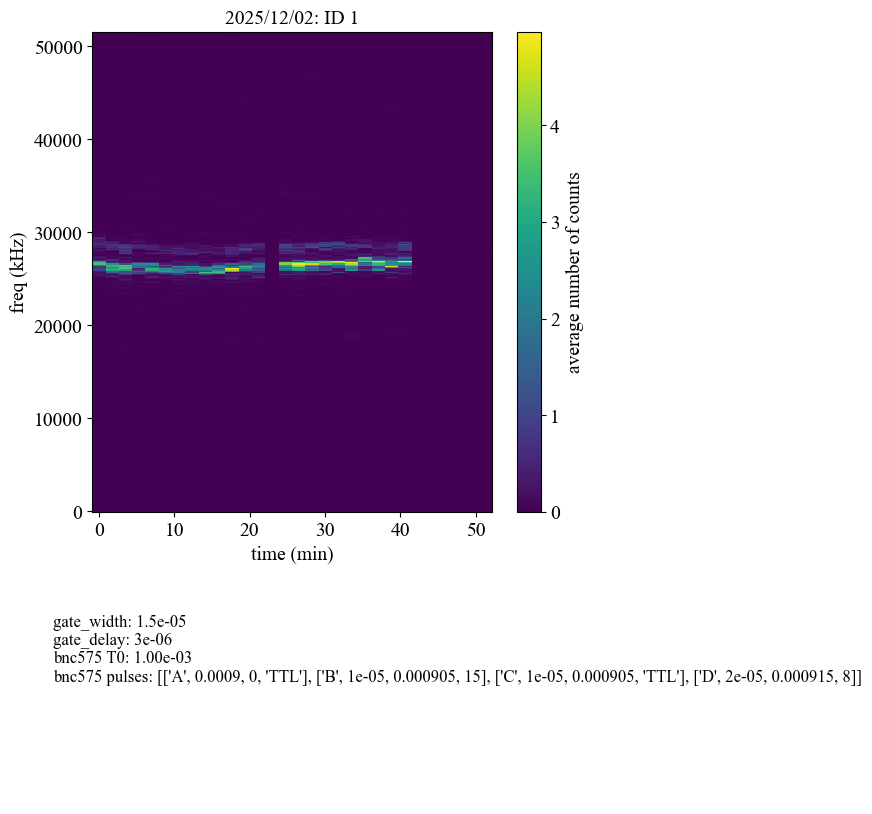

In [53]:
ps.Plot3D(x = np.arange(repeat_num) * 106/60, y = x_list*stride*freq_factor , Z = resultss,
          xlabel = "time (min)", ylabel = "freq (kHz)", zlabel = "average number of counts", notes = notes)

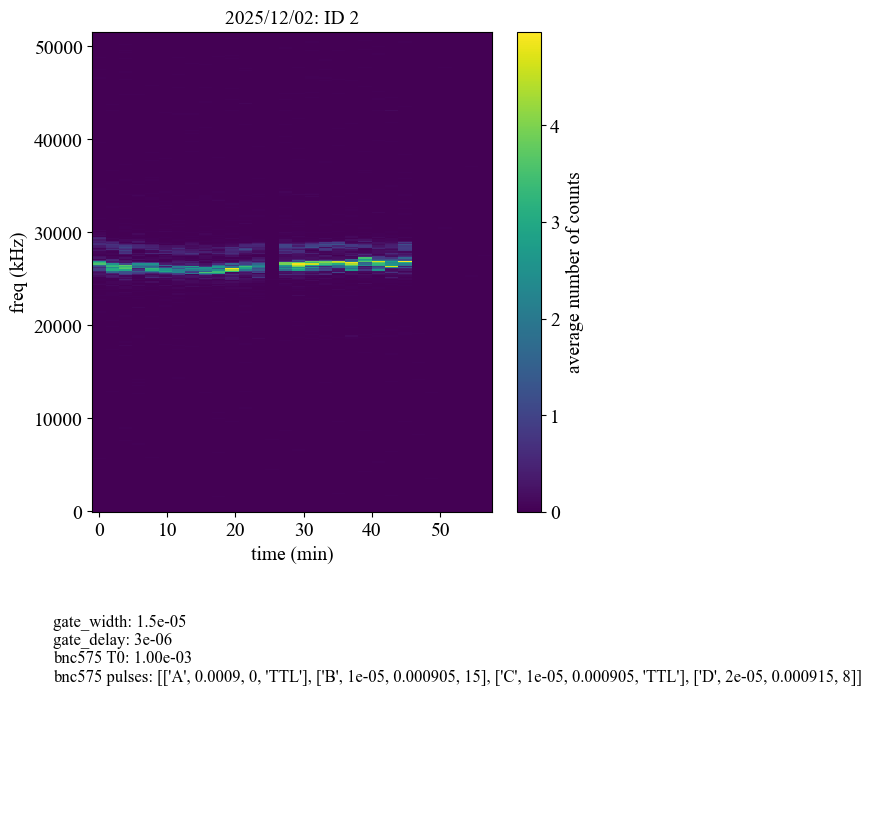

In [54]:
ps.Plot3D(x = np.arange(repeat_num) * 117/60, y = x_list*stride*freq_factor , Z = resultss,
          xlabel = "time (min)", ylabel = "freq (kHz)", zlabel = "average number of counts", notes = notes)

In [57]:
import pandas as pd
import glob
import os
from scipy.signal import find_peaks

In [61]:
np.array(resultss).shape

(30, 400)

In [64]:
len(np.arange(repeat_num))

30

In [68]:
for i in np.arange(repeat_num):
    print(np.max(resultss[i]))

3.533333333333333
3.3
3.7
2.433333333333333
3.2666666666666666
2.933333333333333
2.2666666666666666
2.7666666666666666
3.533333333333333
3.433333333333333
4.9
3.4
2.3666666666666667
0.03333333333333333
3.933333333333333
4.833333333333333
4.566666666666666
4.0
4.533333333333333
4.833333333333333
3.6666666666666665
4.666666666666667
4.666666666666667
4.966666666666667
0.03333333333333333
0.03333333333333333
0.03333333333333333
0.0
0.03333333333333333
0.03333333333333333


In [69]:
peaks, props = find_peaks(resultss[0], height = np.max(resultss[0]))

In [75]:
np.array(resultss)[0][peaks]

array([3.53333333])

In [99]:
peak_locations = []

for i in np.arange(repeat_num-6):
    peaks, props = find_peaks(resultss[i], height = np.max(resultss[i]))
    peak_locations.append(peaks[0])

print(peak_locations)

[206, 204, 205, 206, 202, 200, 199, 204, 199, 199, 202, 204, 204, 35, 206, 206, 206, 207, 208, 207, 208, 208, 204, 208]


In [101]:
freq_data = x_list*stride*freq_factor
print(freq_data[peak_locations[:]])

[26574. 26316. 26445. 26574. 26058. 25800. 25671. 26316. 25671. 25671.
 26058. 26316. 26316.  4515. 26574. 26574. 26574. 26703. 26832. 26703.
 26832. 26832. 26316. 26832.]


Text(0, 0.5, 'frequency [kHz]')

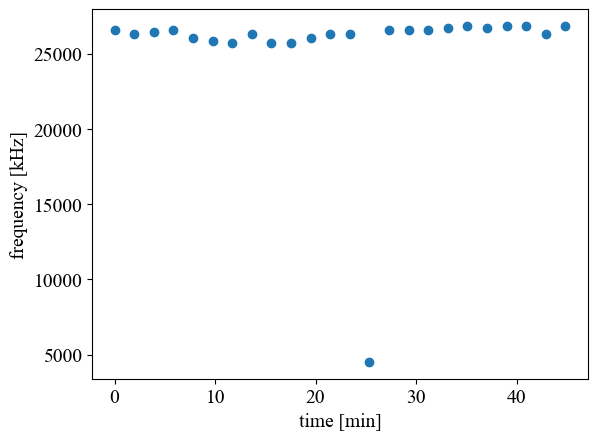

In [104]:
plt.scatter(np.arange(repeat_num - 6) * 117/60, freq_data[peak_locations[:]])
plt.xlabel("time [min]")
plt.ylabel("frequency [kHz]")

In [103]:
x_data = np.arange(repeat_num - 6) * 117/60
y_data = freq_data[peak_locations[:]]

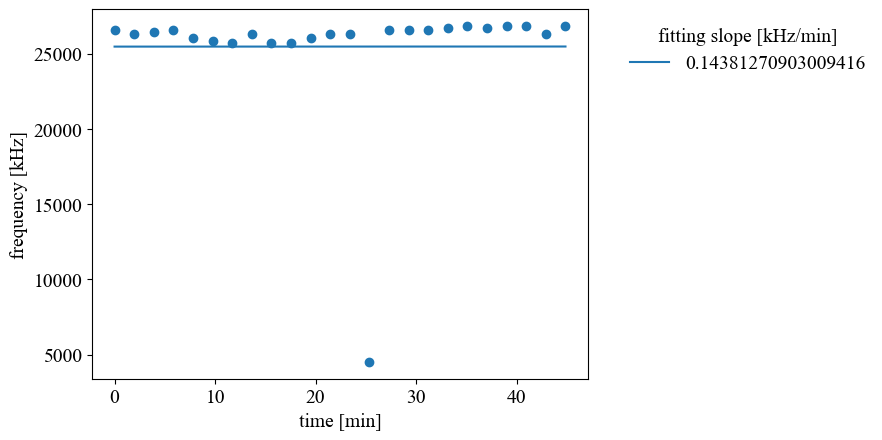

In [112]:
plt.scatter(x_data, y_data)
a, b = np.polyfit(x_data, y_data, 1)
plt.plot(x_data, a*x_data + b, label = f"{a}")
plt.xlabel("time [min]")
plt.ylabel("frequency [kHz]")
plt.legend(title="fitting slope [kHz/min]",bbox_to_anchor=(1.05, 1), loc="upper left")

In [110]:
print(f"the slope is {a} kHz/min.")

the slope is 0.14381270903009416 kHz/min.


# End

In [55]:
mcbox.set_voltage_Nchan(board_num=0,channels= [0,1,6,7,10,11], voltages = [0,0,0,0,0,0], bipolar = True)

Channel 0 has been set to 0 V.
Channel 1 has been set to 0 V.
Channel 6 has been set to 0 V.
Channel 7 has been set to 0 V.
Channel 10 has been set to 0 V.
Channel 11 has been set to 0 V.
Voltages successfully set.


In [56]:
weeder.save(header = "A", query = True)

'saving complete.'

In [78]:
bnc575.disable_all()

In [79]:
bnc575.disarm_all()